<div style="text-align:center;">

# Análisis de Asociación con la Variable Objetivo
### *¿Qué variables se relacionan con la renuncia (Attrition)?*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Propósito

Cuantificar la **relación de cada variable predictora con el target `Attrition`**, eligiendo en cada caso la medida de asociación **estadísticamente correcta** según el tipo de variable.

El target es **binario** (`Yes`=1, `No`=0). Esto es crucial: la correlación de Pearson clásica **no es apropiada** para todos los pares. La medida correcta depende del tipo de la otra variable:

| Par de variables | Medida correcta | Justificación |
|:-----------------|:----------------|:--------------|
| Binaria ↔ numérica **continua** | **Punto-biserial** $r_{pb}$ | Especialización de Pearson cuando una variable es dicotómica codificada 0/1. Rango $[-1, 1]$. |
| Binaria ↔ **ordinal** | **Spearman** $\rho$ | Mide relación **monótona** por rangos; no asume que los niveles ordinales sean equidistantes. Rango $[-1, 1]$. |
| Binaria ↔ **nominal** | **Cramér's V** | Derivada del estadístico $\chi^2$; mide la **fuerza de asociación** entre dos categóricas. Rango $[0, 1]$. |
| Cualquier tipo (transversal) | **Información mutua** $I(X;Y)$ | Captura dependencia **no lineal** y sirve para ambos tipos. "La mejor" medida unificada para comparar todas las variables en una sola escala. |

Estructura del notebook:

1. Boxplots de cada variable numérica frente a `Attrition`.
2. Correlación punto-biserial / Spearman (variables numéricas y ordinales).
3. Cramér's V (variables nominales).
4. Información mutua (todas las variables, escala común).
5. Gráficas de las asociaciones y ranking unificado.


---
## 1. Librerías y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

COLOR_YES, COLOR_NO = "#e74c3c", "#3498db"
PALETTE_ATTR = {"Yes": COLOR_YES, "No": COLOR_NO}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga y clasificación de variables

In [2]:
DATA_PATH = Path.cwd().parent.parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# Descartamos columnas sin información
COLS_DESCARTAR = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=COLS_DESCARTAR)

# Target binario
y = (df["Attrition"] == "Yes").astype(int)

# Clasificación por tipo (consistente con 0.Exploracion_Inicial)
COLS_NOMINALES = ["BusinessTravel", "Department", "EducationField",
                  "Gender", "JobRole", "MaritalStatus", "OverTime"]

COLS_ORDINALES = ["Education", "EnvironmentSatisfaction", "JobInvolvement",
                  "JobLevel", "JobSatisfaction", "PerformanceRating",
                  "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance"]

COLS_CONTINUAS = ["Age", "DailyRate", "DistanceFromHome", "HourlyRate",
                  "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked",
                  "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
                  "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion",
                  "YearsWithCurrManager"]

print(f"  Continuas : {len(COLS_CONTINUAS)}")
print(f"  Ordinales : {len(COLS_ORDINALES)}")
print(f"  Nominales : {len(COLS_NOMINALES)}")
print(f"  Target    : Attrition (Yes={y.sum()}, No={(y==0).sum()})")

  Continuas : 14
  Ordinales : 9
  Nominales : 7
  Target    : Attrition (Yes=237, No=1233)


---
## 3. Boxplots de cada variable numérica frente a `Attrition`

El boxplot permite comparar la **distribución** de cada variable entre quienes renunciaron (`Yes`) y quienes permanecieron (`No`). Cuando las dos cajas están claramente desplazadas, la variable **discrimina** bien entre clases.

> Los boxplots aplican a variables **numéricas y ordinales**. Para variables nominales se usan tasas por categoría (ver `0.Exploracion_Inicial.ipynb`, sección 8) y la asociación se cuantifica con Cramér's V en la sección 5.


### 3.1 Variables continuas

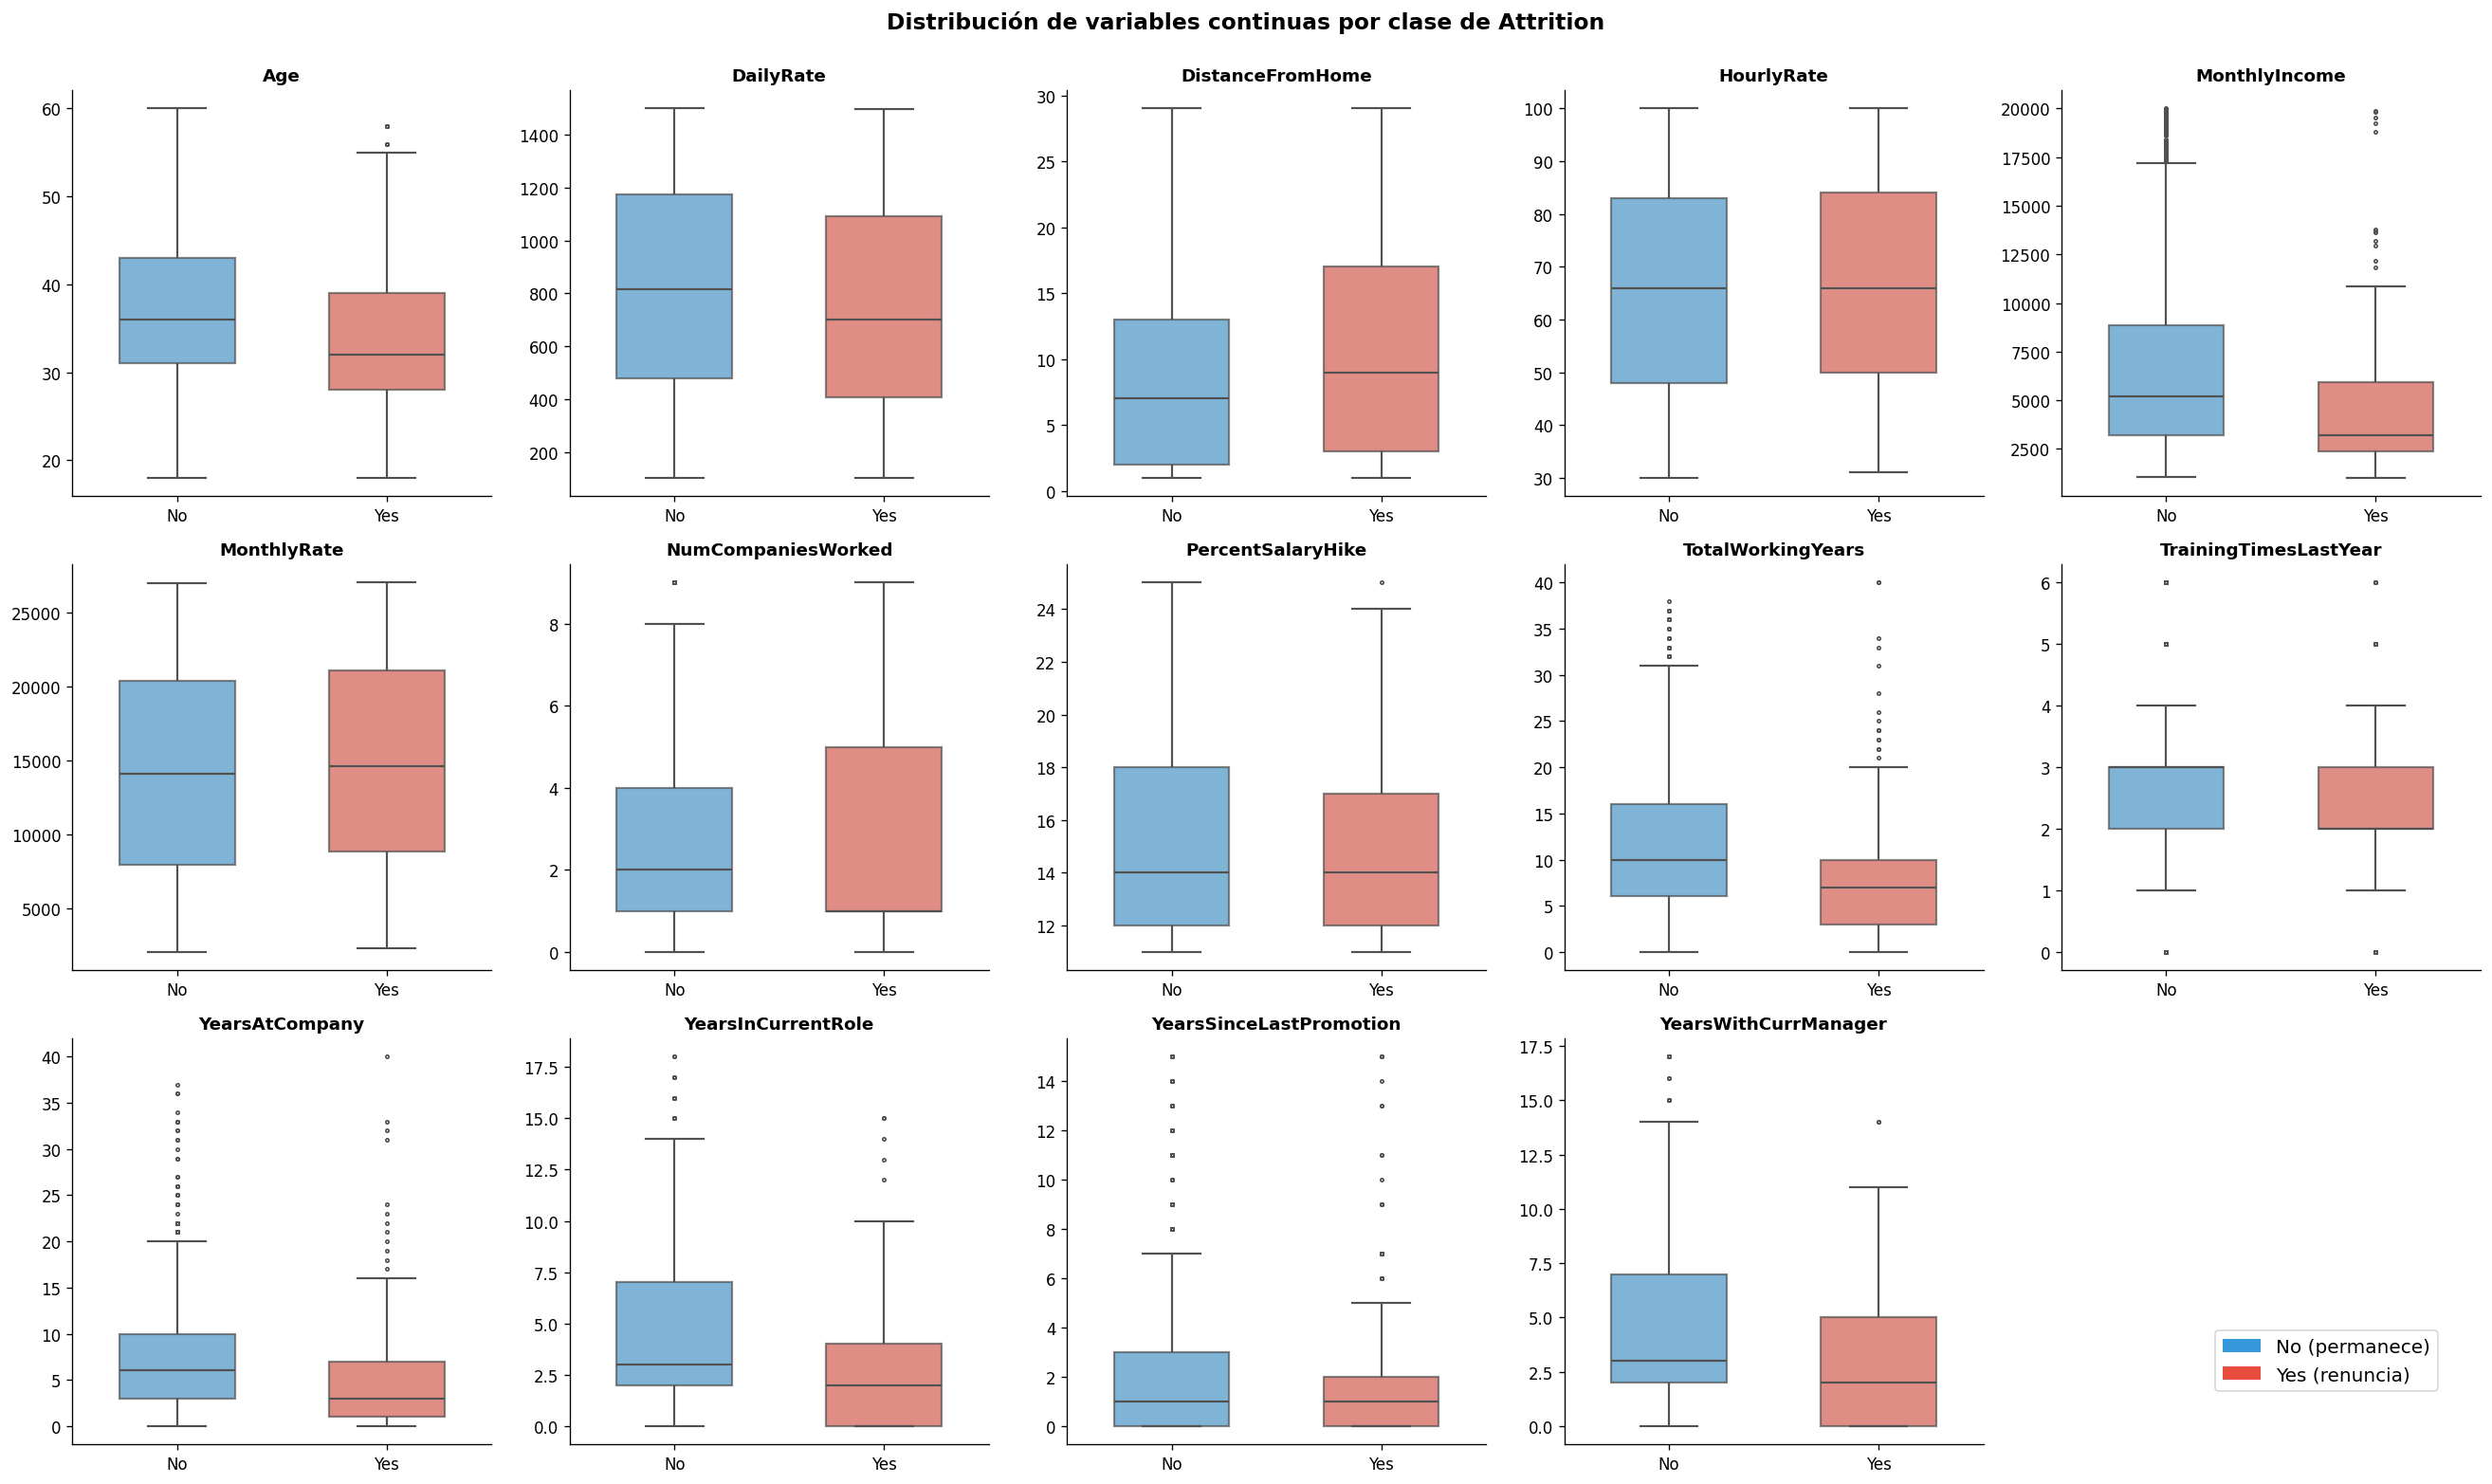

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, col in zip(axes, COLS_CONTINUAS):
    sns.boxplot(data=df, x="Attrition", y=col, order=["No", "Yes"],
                palette=PALETTE_ATTR, ax=ax, width=0.55,
                fliersize=2, linewidth=1.3, boxprops=dict(alpha=0.7))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Ocultar ejes sobrantes
for ax in axes[len(COLS_CONTINUAS):]:
    ax.set_visible(False)

handles = [Patch(facecolor=COLOR_NO,  label="No (permanece)"),
           Patch(facecolor=COLOR_YES, label="Yes (renuncia)")]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.98, 0.06),
           fontsize=12, frameon=True, fancybox=True)

fig.suptitle("Distribución de variables continuas por clase de Attrition",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### 3.2 Variables ordinales

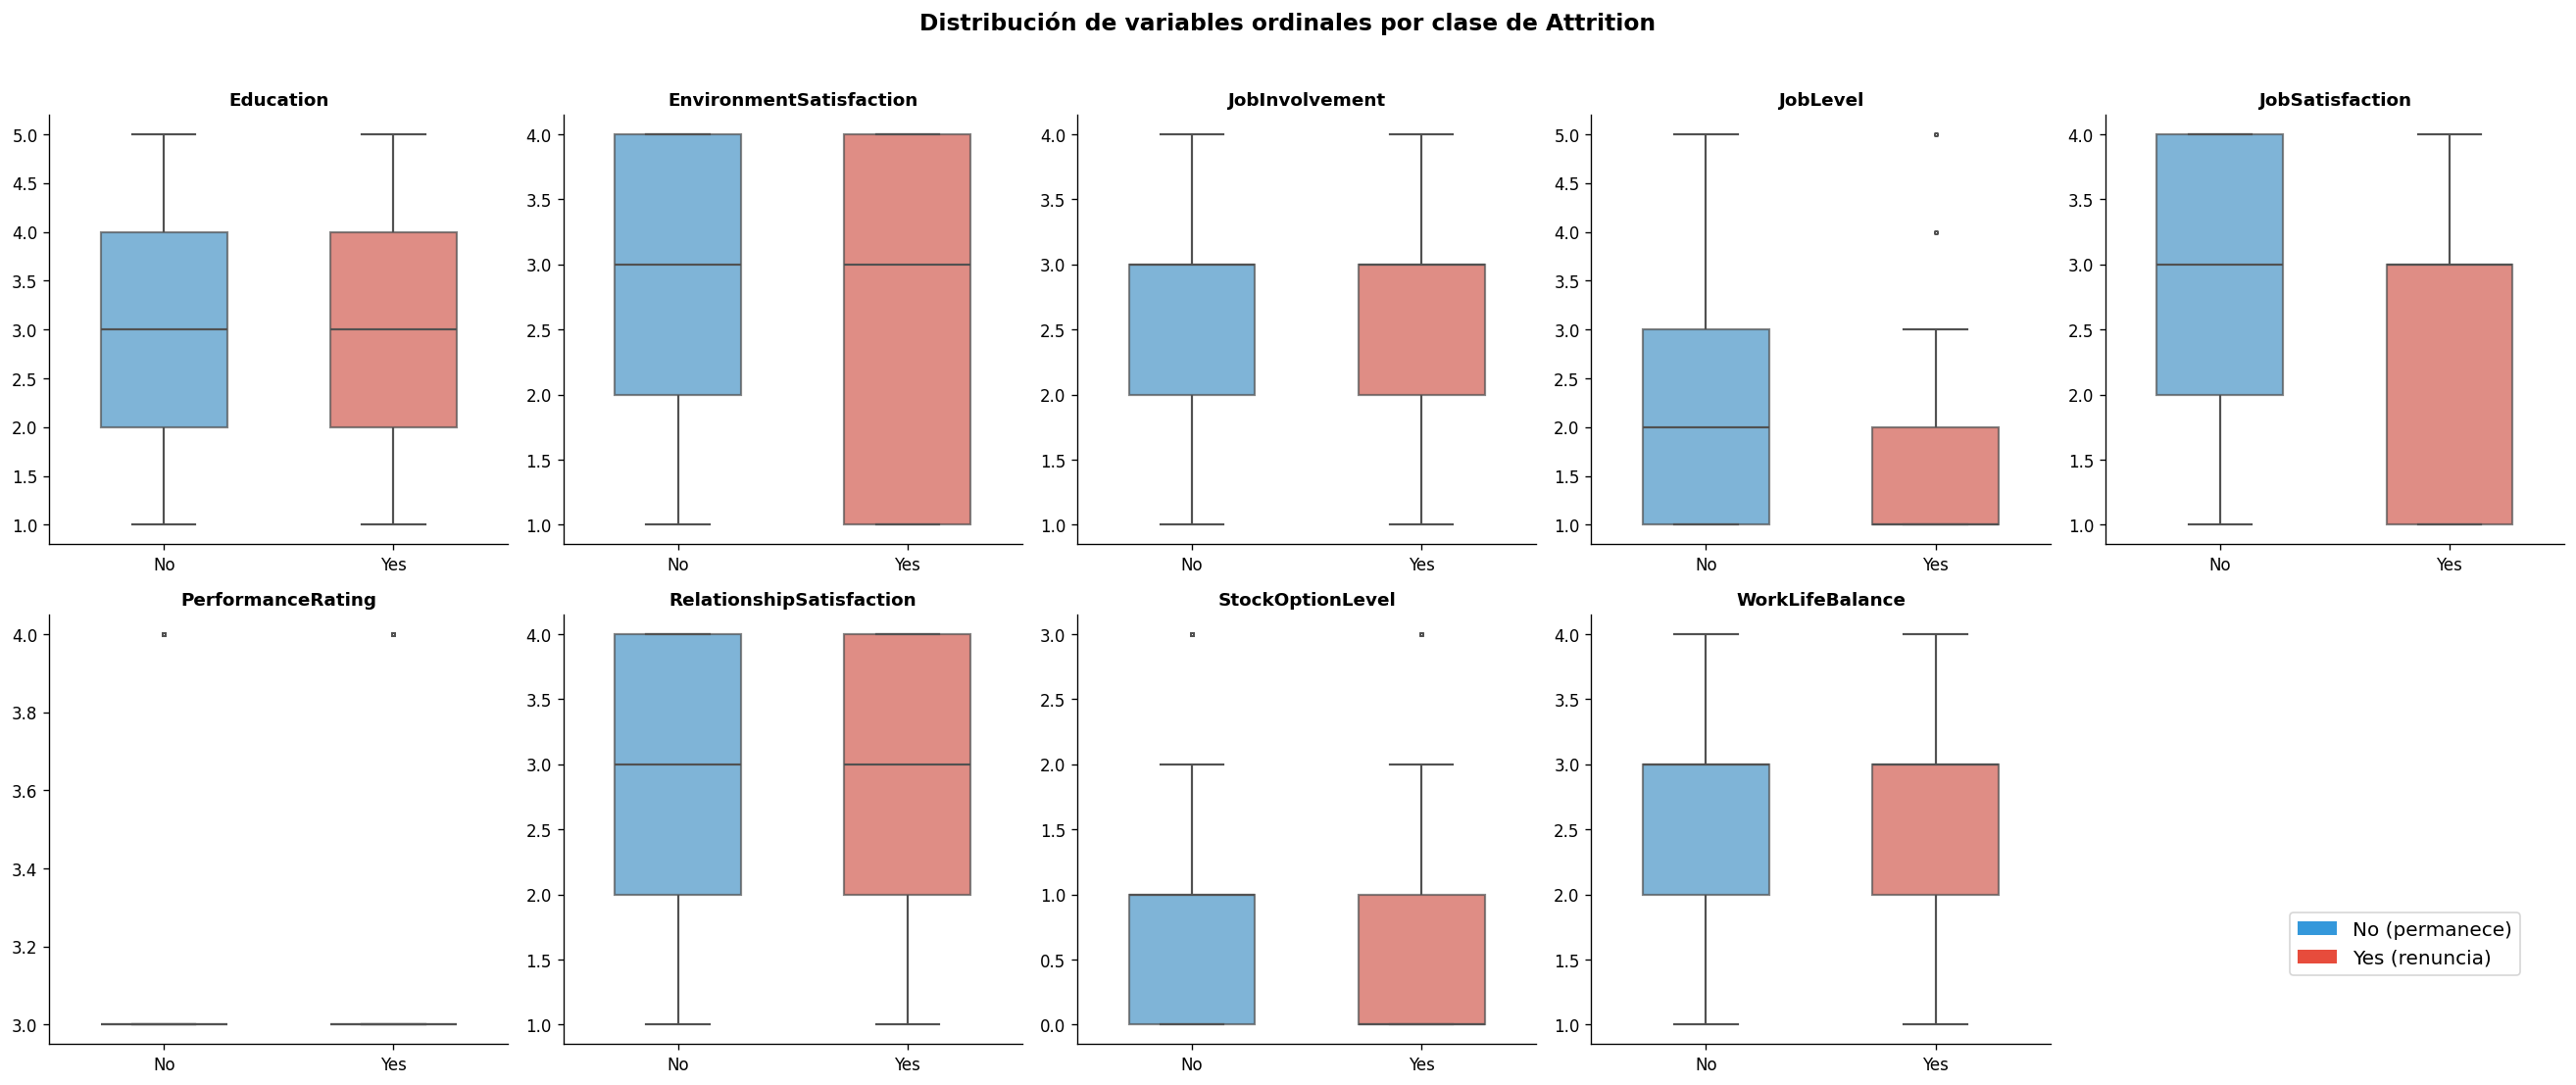

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, col in zip(axes, COLS_ORDINALES):
    sns.boxplot(data=df, x="Attrition", y=col, order=["No", "Yes"],
                palette=PALETTE_ATTR, ax=ax, width=0.55,
                fliersize=2, linewidth=1.3, boxprops=dict(alpha=0.7))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(COLS_ORDINALES):]:
    ax.set_visible(False)

handles = [Patch(facecolor=COLOR_NO,  label="No (permanece)"),
           Patch(facecolor=COLOR_YES, label="Yes (renuncia)")]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.98, 0.10),
           fontsize=12, frameon=True, fancybox=True)

fig.suptitle("Distribución de variables ordinales por clase de Attrition",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Correlación numérica ↔ target

### 4.1 ¿Por qué punto-biserial y no Pearson directo?

La correlación **punto-biserial** $r_{pb}$ es el caso particular de Pearson cuando una de las variables es **dicotómica** (0/1). Para una variable continua $X$ y el target binario $Y$:

$$
r_{pb} = \frac{\bar{X}_1 - \bar{X}_0}{s_X}\sqrt{\frac{n_1\,n_0}{n^2}}
$$

donde $\bar{X}_1, \bar{X}_0$ son las medias de $X$ en cada clase, $s_X$ la desviación de $X$, y $n_1, n_0$ los tamaños de clase. Mide qué tanto **se separan las medias** de la variable entre los dos grupos.

Para las variables **ordinales** usamos **Spearman** $\rho$ (correlación de rangos), que es más apropiada porque no asume que los niveles ordinales sean equidistantes — solo que mantienen un orden.


In [5]:
# ── Punto-biserial para continuas ────────────────────────────────────────
filas_cont = []
for col in COLS_CONTINUAS:
    r, p = pointbiserialr(y, df[col])
    filas_cont.append({"Variable": col, "Tipo": "Continua",
                       "Medida": "Punto-biserial", "Coef.": r,
                       "|Coef.|": abs(r), "p-valor": p})

# ── Spearman para ordinales ───────────────────────────────────────────────
filas_ord = []
for col in COLS_ORDINALES:
    rho, p = spearmanr(y, df[col])
    filas_ord.append({"Variable": col, "Tipo": "Ordinal",
                      "Medida": "Spearman", "Coef.": rho,
                      "|Coef.|": abs(rho), "p-valor": p})

tabla_num = pd.DataFrame(filas_cont + filas_ord)
tabla_num = tabla_num.sort_values("|Coef.|", ascending=False).reset_index(drop=True)
tabla_num["Significativa (α=0.05)"] = tabla_num["p-valor"] < 0.05
tabla_num.round(4)

,Variable,Tipo,Medida,Coef.,|Coef.|,p-valor,Significativa (α=0.05)
0,JobLevel,Ordinal,Spearman,-0.1904,0.1904,0.0000,True
1,StockOptionLevel,Ordinal,Spearman,-0.1723,0.1723,0.0000,True
2,TotalWorkingYears,Continua,Punto-biserial,-0.1711,0.1711,0.0000,True
3,YearsInCurrentRole,Continua,Punto-biserial,-0.1605,0.1605,0.0000,True
4,MonthlyIncome,Continua,Punto-biserial,-0.1598,0.1598,0.0000,True
5,Age,Continua,Punto-biserial,-0.1592,0.1592,0.0000,True
6,YearsWithCurrManager,Continua,Punto-biserial,-0.1562,0.1562,0.0000,True
7,YearsAtCompany,Continua,Punto-biserial,-0.1344,0.1344,0.0000,True
8,JobInvolvement,Ordinal,Spearman,-0.1195,0.1195,0.0000,True
9,JobSatisfaction,Ordinal,Spearman,-0.1029,0.1029,0.0001,True


**Lectura del signo:**

- Coeficiente **positivo** → a mayor valor de la variable, mayor probabilidad de renuncia.
- Coeficiente **negativo** → a mayor valor de la variable, menor probabilidad de renuncia.


---
## 5. Asociación nominal ↔ target — Cramér's V

### 5.1 ¿Por qué Cramér's V?

Para dos variables **categóricas** no existe "correlación" en el sentido de Pearson. La medida estándar de asociación es **Cramér's V**, derivada del estadístico $\chi^2$ de independencia:

$$
V = \sqrt{\frac{\chi^2 / n}{\min(k-1,\, r-1)}}
$$

donde $n$ es el tamaño muestral, y $k, r$ el número de categorías de cada variable. $V \in [0, 1]$: 0 = independencia total, 1 = asociación perfecta. Aplicamos la **corrección de sesgo de Bergsma**, recomendada para tablas pequeñas.


In [6]:
def cramers_v(x, y):
    """Cramér's V con corrección de sesgo (Bergsma-Wicher)."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    # Corrección de sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

filas_nom = []
for col in COLS_NOMINALES:
    v = cramers_v(df[col], df["Attrition"])
    # p-valor del test chi-cuadrado de independencia
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[col], df["Attrition"]))
    filas_nom.append({"Variable": col, "Tipo": "Nominal",
                      "Medida": "Cramér's V", "Cramér's V": v,
                      "p-valor (χ²)": p,
                      "Significativa (α=0.05)": p < 0.05})

tabla_nom = pd.DataFrame(filas_nom).sort_values("Cramér's V", ascending=False).reset_index(drop=True)
tabla_nom.round(4)

,Variable,Tipo,Medida,Cramér's V,p-valor (χ²),Significativa (α=0.05)
0,OverTime,Nominal,Cramér's V,0.2427,0.0000,True
1,JobRole,Nominal,Cramér's V,0.2307,0.0000,True
2,MaritalStatus,Nominal,Cramér's V,0.1734,0.0000,True
3,BusinessTravel,Nominal,Cramér's V,0.1229,0.0000,True
4,EducationField,Nominal,Cramér's V,0.0866,0.0068,True
5,Department,Nominal,Cramér's V,0.0774,0.0045,True
6,Gender,Nominal,Cramér's V,0.0089,0.2906,False


> A diferencia de la correlación, Cramér's V **no tiene signo** (siempre $\geq 0$): mide la fuerza de la asociación, no su dirección. Para conocer qué categorías concretas elevan la tasa de renuncia, ver el análisis por categoría en `0.Exploracion_Inicial.ipynb`.


---
## 6. Información mutua — la mejor medida transversal

La **información mutua** $I(X;Y)$ mide cuánta información aporta una variable sobre el target, **sin asumir linealidad ni monotonía**. Es la medida más general:

$$
I(X;Y) = \sum_{x}\sum_{y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}
$$

Vale 0 si y solo si $X$ e $Y$ son **independientes**, y crece con la dependencia (sea lineal o no). Su gran ventaja: permite comparar variables continuas, ordinales y nominales en **una sola escala**, algo imposible mezclando punto-biserial con Cramér's V.


In [7]:
# Preparamos X con todas las variables; las categóricas se codifican con LabelEncoder
X_mi = df.drop(columns=["Attrition"]).copy()

# Codificación de nominales (solo para info mutua)
for col in COLS_NOMINALES:
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col])

# Marcamos qué columnas son discretas (ordinales + nominales)
cols_discretas = COLS_ORDINALES + COLS_NOMINALES
discrete_mask = [c in cols_discretas for c in X_mi.columns]

mi = mutual_info_classif(X_mi, y, discrete_features=discrete_mask, random_state=42)

tabla_mi = pd.DataFrame({
    "Variable": X_mi.columns,
    "Tipo": ["Nominal" if c in COLS_NOMINALES
             else "Ordinal" if c in COLS_ORDINALES
             else "Continua" for c in X_mi.columns],
    "Información Mutua": mi,
}).sort_values("Información Mutua", ascending=False).reset_index(drop=True)
tabla_mi.round(4)

,Variable,Tipo,Información Mutua
0,MonthlyIncome,Continua,0.0336
1,JobRole,Nominal,0.0302
2,YearsWithCurrManager,Continua,0.0285
3,OverTime,Nominal,0.0277
4,YearsInCurrentRole,Continua,0.0269
5,JobLevel,Ordinal,0.0250
6,Age,Continua,0.0235
7,StockOptionLevel,Ordinal,0.0210
8,YearsAtCompany,Continua,0.0189
9,MaritalStatus,Nominal,0.0150


---
## 7. Visualización de las asociaciones

### 7.1 Correlación numérica ↔ target (con signo)

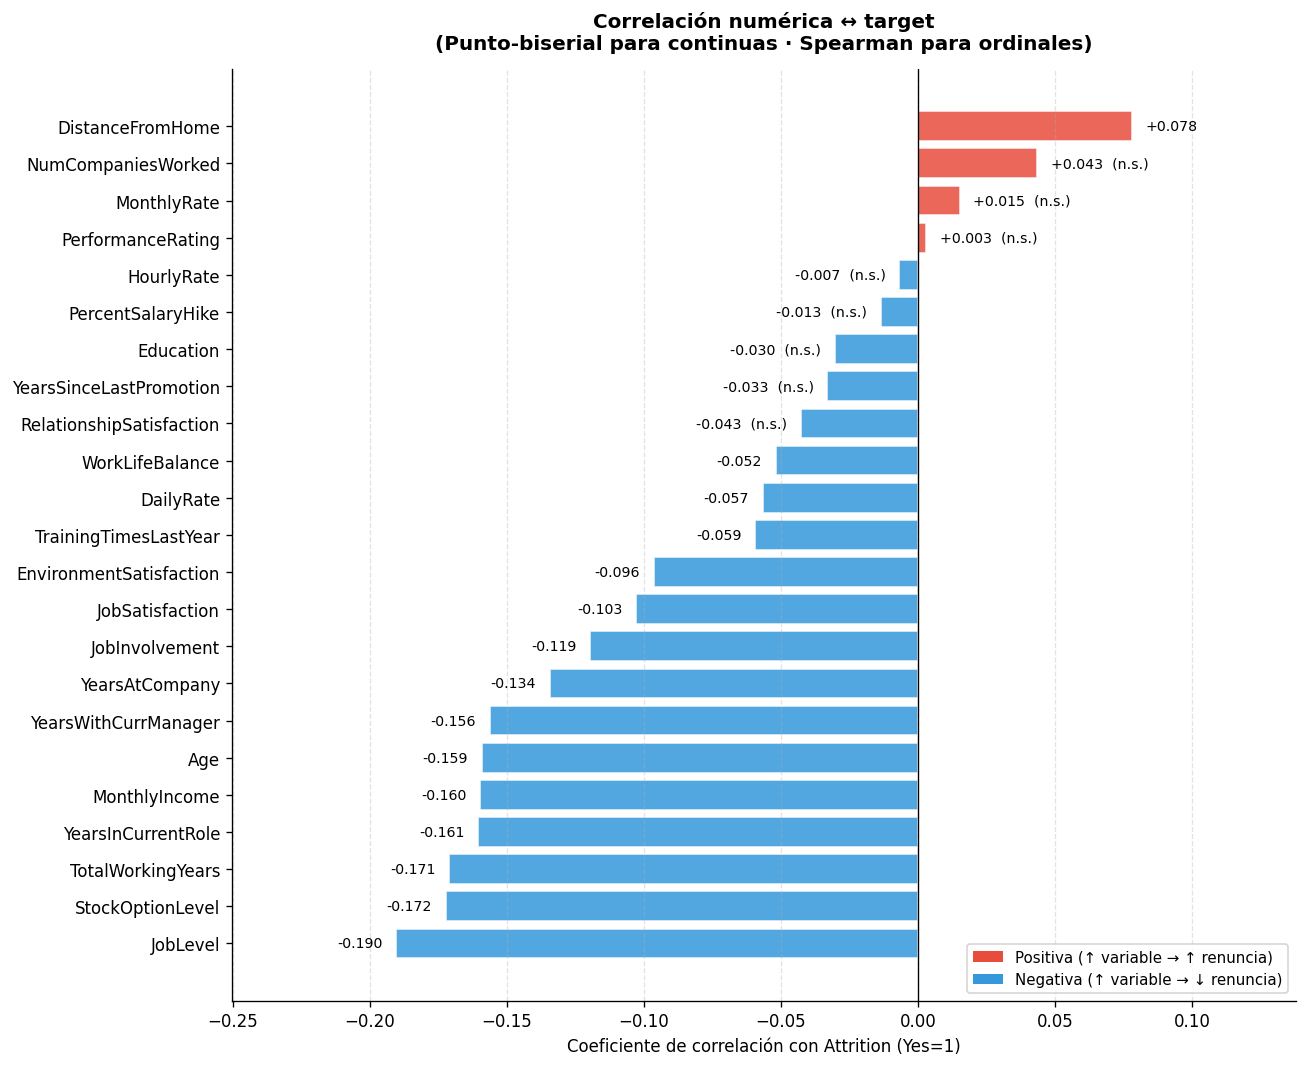

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))

datos = tabla_num.sort_values("Coef.")
colores = [COLOR_YES if c > 0 else COLOR_NO for c in datos["Coef."]]

bars = ax.barh(datos["Variable"], datos["Coef."], color=colores,
               edgecolor="white", alpha=0.85)

for b, v, sig in zip(bars, datos["Coef."], datos["Significativa (α=0.05)"]):
    offset = 0.005 if v >= 0 else -0.005
    ha = "left" if v >= 0 else "right"
    marca = "" if sig else "  (n.s.)"
    ax.text(v + offset, b.get_y() + b.get_height()/2,
            f"{v:+.3f}{marca}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente de correlación con Attrition (Yes=1)")
ax.set_title("Correlación numérica ↔ target\n(Punto-biserial para continuas · Spearman para ordinales)",
             fontsize=12, pad=12)
ax.set_xlim(datos["Coef."].min() - 0.06, datos["Coef."].max() + 0.06)

handles = [Patch(facecolor=COLOR_YES, label="Positiva (↑ variable → ↑ renuncia)"),
           Patch(facecolor=COLOR_NO,  label="Negativa (↑ variable → ↓ renuncia)")]
ax.legend(handles=handles, loc="lower right", frameon=True, fancybox=True, fontsize=9)
ax.grid(axis="x", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 7.2 Asociación nominal ↔ target (Cramér's V)

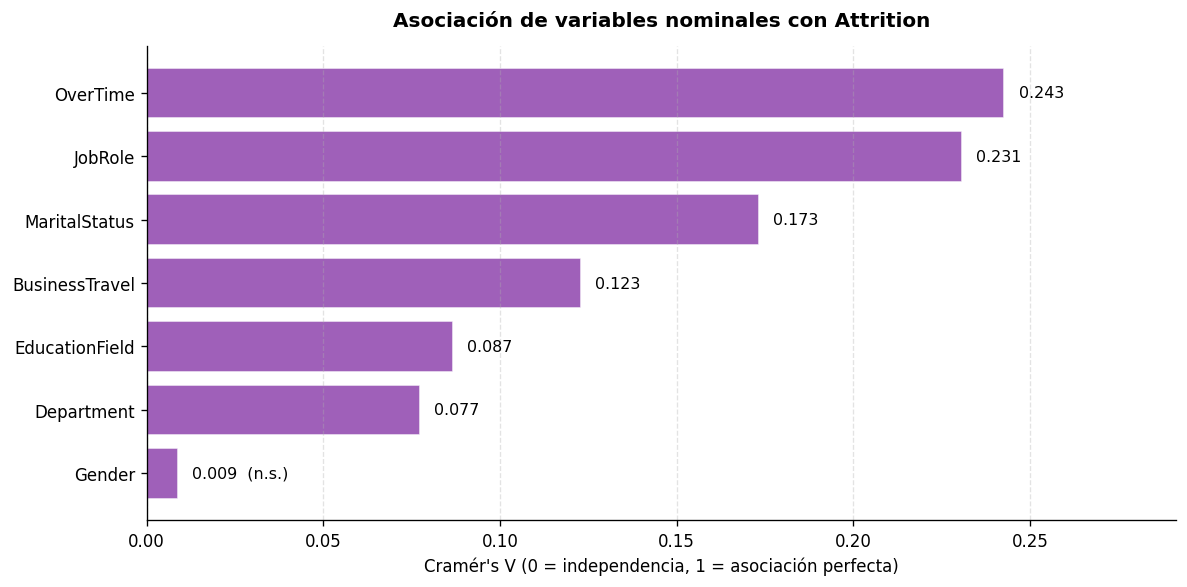

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

datos = tabla_nom.sort_values("Cramér's V")
bars = ax.barh(datos["Variable"], datos["Cramér's V"],
               color="#8e44ad", edgecolor="white", alpha=0.85)

for b, v, sig in zip(bars, datos["Cramér's V"], datos["Significativa (α=0.05)"]):
    marca = "" if sig else "  (n.s.)"
    ax.text(v + 0.004, b.get_y() + b.get_height()/2,
            f"{v:.3f}{marca}", va="center", fontsize=9.5)

ax.set_xlabel("Cramér's V (0 = independencia, 1 = asociación perfecta)")
ax.set_title("Asociación de variables nominales con Attrition", fontsize=12, pad=12)
ax.set_xlim(0, datos["Cramér's V"].max() * 1.20)
ax.grid(axis="x", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 7.3 Ranking unificado — Información mutua (todas las variables)

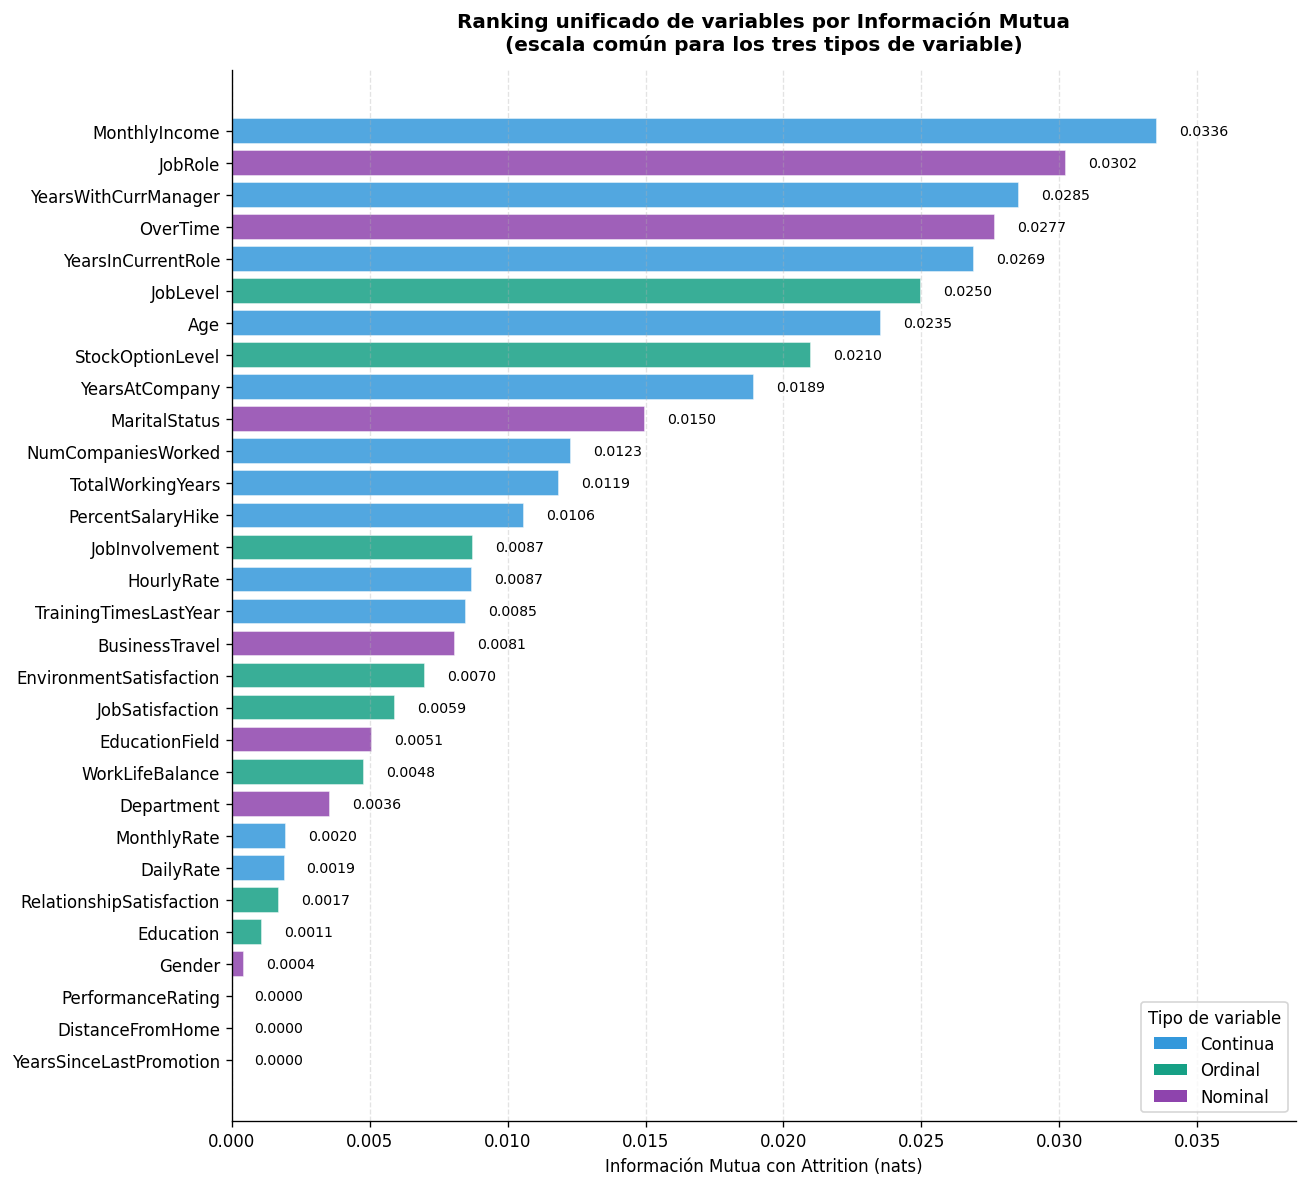

In [10]:
fig, ax = plt.subplots(figsize=(11, 10))

datos = tabla_mi.sort_values("Información Mutua")
mapa_color = {"Continua": "#3498db", "Ordinal": "#16a085", "Nominal": "#8e44ad"}
colores = [mapa_color[t] for t in datos["Tipo"]]

bars = ax.barh(datos["Variable"], datos["Información Mutua"],
               color=colores, edgecolor="white", alpha=0.85)

for b, v in zip(bars, datos["Información Mutua"]):
    ax.text(v + 0.0008, b.get_y() + b.get_height()/2,
            f"{v:.4f}", va="center", fontsize=8.5)

ax.set_xlabel("Información Mutua con Attrition (nats)")
ax.set_title("Ranking unificado de variables por Información Mutua\n(escala común para los tres tipos de variable)",
             fontsize=12, pad=12)
ax.set_xlim(0, datos["Información Mutua"].max() * 1.15)

handles = [Patch(facecolor=mapa_color[t], label=t) for t in ["Continua", "Ordinal", "Nominal"]]
ax.legend(handles=handles, loc="lower right", frameon=True, fancybox=True,
          fontsize=10, title="Tipo de variable")
ax.grid(axis="x", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

---
## 8. Síntesis

### Qué medida se usó y por qué

| Tipo de variable | Medida aplicada | Rango | Interpreta |
|:-----------------|:----------------|:------|:-----------|
| Continua         | Punto-biserial $r_{pb}$ | $[-1,1]$ | Separación de medias entre clases (con signo) |
| Ordinal          | Spearman $\rho$ | $[-1,1]$ | Relación monótona por rangos (con signo) |
| Nominal          | Cramér's V | $[0,1]$ | Fuerza de asociación (sin signo) |
| Todas            | Información mutua | $[0,\infty)$ | Dependencia general, lineal o no (sin signo) |

### Cómo leer los resultados en conjunto

- Las correlaciones **con signo** (punto-biserial, Spearman) dicen la **dirección** del efecto: qué variables empujan hacia la renuncia y cuáles hacia la permanencia.
- Cramér's V y la información mutua dicen la **fuerza** de la relación pero no su dirección — útiles para variables nominales donde "dirección" no tiene sentido único.
- La **información mutua** es la única que pone las tres familias de variables en una escala comparable, por lo que es la referencia para un **ranking global de importancia** previo al modelado.

> Estas asociaciones son **marginales** (variable a variable). No capturan interacciones ni el efecto de una variable controlando por las demás — eso lo hacen los modelos multivariados (coeficientes de la regresión logística, importancias de los árboles) en las fases posteriores del laboratorio.
